# Substrate–Inhibitor 2D Demo

In this notebook, we simulate the substrate–inhibitor reaction–diffusion system in two spatial dimensions using the AB2–AM2 scheme.

The aim is to visualise how Turing instability produces spatial patterns from a small perturbation of the homogeneous steady state. Compared with the Schnakenberg system, this model includes a saturating inhibition term, which can make the resulting patterns more sensitive to parameter choice.

The observed pattern depends on:
- the diffusion ratio $d$,
- the parameters controlling the inhibition term,
- the domain size and aspect ratio,
- the unstable spatial modes selected by the dispersion relation,
- and the nonlinear interaction between growing modes.

In [1]:
import sys
import os
sys.path.append(os.path.abspath("../.."))

import numpy as np
import matplotlib.pyplot as plt

from src.solvers import AB2AM2Solver2D
from src.models import SubstrateInhibitorModel
from src.visualiser import plot_2D_both, plot_2D_U, plot_2D_cases, animate_2D_both

## 1. Single 2D simulation

We begin with a single two-dimensional simulation on a square domain. The initial condition is a small random perturbation of the homogeneous steady state.

As in the Schnakenberg case, random perturbations contain many spatial frequencies. The Turing mechanism amplifies unstable modes while stable modes decay. The final pattern is then shaped by nonlinear saturation and the rational inhibition term.

In [4]:
params = {
    "a": 150.0,
    "b": 100.0,
    "alpha": 1.5,
    "rho": 13.0,
    "K": 0.05,
    "gamma": 3.0,
    "d": 50.0
}

solver = AB2AM2Solver2D(
    model=SubstrateInhibitorModel,
    params=params,
    Lx=100,
    Ly=100,
    Nx=200,
    Ny=200,
    T=100,
    dt=0.01,
    save_every=20
)

t, U, V, x, y, X, Y = solver.run(p_type="random")

print("Ran successfully:", U.shape)

Ran successfully: (501, 200, 200)


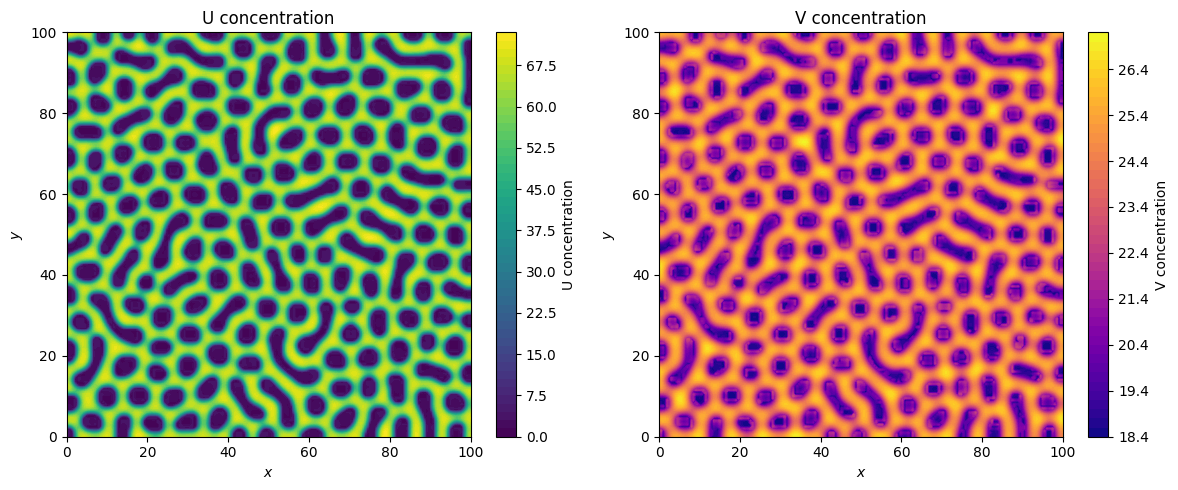

In [6]:
plot_2D_both(X, Y, U[-1], V[-1])

## 2. Effect of domain geometry

In two dimensions, the substrate–inhibitor system is particularly sensitive to the shape and size of the spatial domain.

While the linear instability determines which spatial modes can grow, the domain geometry restricts which of these modes can actually be realised. As a result, changing the domain dimensions can significantly alter the observed pattern, even when the reaction parameters are fixed.

In particular:
- a **square domain** allows multiple competing modes, often leading to irregular or fragmented structures,
- a **long, thin domain** restricts variation in one direction, encouraging alignment of patterns into bands,
- **rectangular domains with moderate aspect ratio** produce mixed behaviour, where no single mode clearly dominates.

This sensitivity reflects the stronger nonlinear coupling in the substrate–inhibitor system, where the saturating inhibition term amplifies the influence of domain constraints on the final pattern.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Spots / fragmented spots
params = {
    "a": 150.0, "b": 100.0,
    "alpha": 1.5, "rho": 13.0, "K": 0.05,
    "gamma": 2.0, "d": 50.0
}
solver = AB2AM2Solver2D(
    model=SubstrateInhibitorModel,
    params=params,
    Lx=100, Ly=100,
    Nx=100, Ny=100,
    T=150, dt=0.1
)

t, U, V, x, y, X, Y = solver.run(p_type="random")
c1 = axes[0].contourf(X, Y, U[-1], cmap="viridis", levels=50)
axes[0].set_title("Spots / fragments")
axes[0].set_xlabel(r"$x$")
axes[0].set_ylabel(r"$y$")
plt.colorbar(c1, ax=axes[0], fraction=0.046, pad=0.04)


# Stripes
params = {
    "a": 150.0, "b": 100.0,
    "alpha": 1.5, "rho": 13.0, "K": 0.05,
    "gamma": 2.0, "d": 40.0
}
solver = AB2AM2Solver2D(
    model=SubstrateInhibitorModel,
    params=params,
    Lx=120, Ly=15,
    Nx=150, Ny=40,
    T=250, dt=0.1
)

t, U, V, x, y, X, Y = solver.run(p_type="random")
c2 = axes[1].contourf(X, Y, U[-1], cmap="viridis", levels=50)
axes[1].set_title("Stripes")
axes[1].set_xlabel(r"$x$")
axes[1].set_ylabel(r"$y$")
plt.colorbar(c2, ax=axes[1], fraction=0.046, pad=0.04)


# Mixed / irregular
params = {
    "a": 150.0, "b": 100.0,
    "alpha": 1.5, "rho": 13.0, "K": 0.05,
    "gamma": 2.0, "d": 30.0
}
solver = AB2AM2Solver2D(
    model=SubstrateInhibitorModel,
    params=params,
    Lx=120, Ly=80,
    Nx=120, Ny=80,
    T=200, dt=0.1
)

t, U, V, x, y, X, Y = solver.run(p_type="random")
c3 = axes[2].contourf(X, Y, U[-1], cmap="viridis", levels=50)
axes[2].set_title("Mixed pattern")
axes[2].set_xlabel(r"$x$")
axes[2].set_ylabel(r"$y$")
plt.colorbar(c3, ax=axes[2], fraction=0.046, pad=0.04)

plt.suptitle("Substrate–inhibitor pattern morphology", fontsize=16)
plt.tight_layout()
plt.show()

## 3. Comparing diffusion ratios

We now compare several diffusion ratios while keeping the reaction parameters fixed. This shows how the substrate–inhibitor patterns change as differential diffusion becomes stronger.

In [15]:
d_vals = [40, 50, 60]
results = {}

for d_val in d_vals:
    params = {
        "a": 160.0,
        "b": 110.0,
        "alpha": 1.5,
        "rho": 13.0,
        "K": 0.05,
        "gamma": 3.0,
        "d": d_val
    }

    solver = AB2AM2Solver2D(
        model=SubstrateInhibitorModel,
        params=params,
        Lx=50,
        Ly=50,
        Nx=100,
        Ny=100,
        T=150,
        dt=0.01,
        save_every=50
    )

    t, U, V, x, y, X, Y = solver.run(p_type="random")
    results[d_val] = (X, Y, U[-1], V[-1])

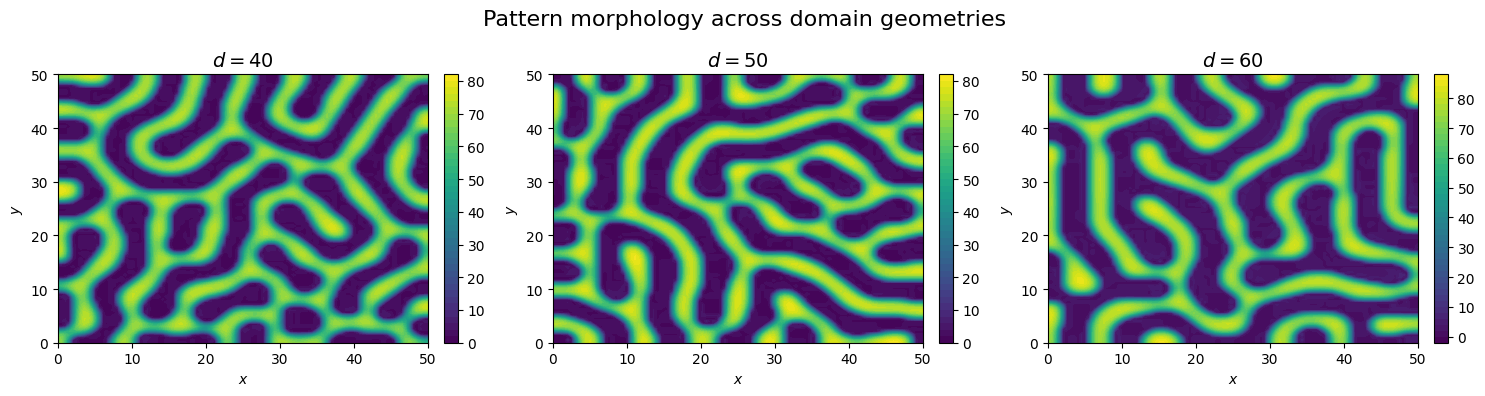

In [16]:
cases = []

for d_val in d_vals:
    X, Y, U_final, V_final = results[d_val]
    cases.append((X, Y, U_final, fr"$d = {d_val}$"))

plot_2D_cases(cases)

## 4. Animation

Finally, we save a GIF of the evolving $U$ and $V$ fields. This visualises how the initial perturbation is amplified and reorganised into a spatial pattern.

In [ ]:
params = {
    "a": 150.0,
    "b": 100.0,
    "alpha": 1.5,
    "rho": 13.0,
    "K": 0.05,
    "gamma": 2.0,
    "d": 50.0
}

solver = AB2AM2Solver2D(
    model=SubstrateInhibitorModel,
    params=params,
    Lx=100,
    Ly=100,
    Nx=100,
    Ny=100,
    T=150,
    dt=0.1,
    save_every=10
)

t, U_hist, V_hist, x, y, X, Y = solver.run(p_type="random")

animate_2D_both(
    X,
    Y,
    U_hist,
    V_hist,
    filename="../../outputs/gifs/substrate_inhibitor_2D_both.gif",
    fps=8,
    title="Substrate–inhibitor reaction–diffusion dynamics"
)

## 5. Conclusion

The 2D simulations show that the substrate–inhibitor model can also generate spatially heterogeneous patterns through diffusion-driven instability.

Compared with the Schnakenberg model, the resulting morphologies are more sensitive to parameter choice because of the saturating inhibition term. This leads to patterns that can appear more fragmented, irregular, or strongly dependent on diffusion ratio and domain geometry.

This demonstrates that while the Turing mechanism provides the linear route to instability, the final spatial pattern is strongly shaped by the specific nonlinear reaction kinetics.